# Structural robustness of mammalian transcription factor networks reveals plasticity across development

## Mouse Analysis

### External imports

In [4]:
import os
import pandas as pd
from io import BytesIO
import networkx as nx
from PIL import Image
import inspect
import numpy as np
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from itertools import chain
import re
import time
import random

### Extracción de las redes

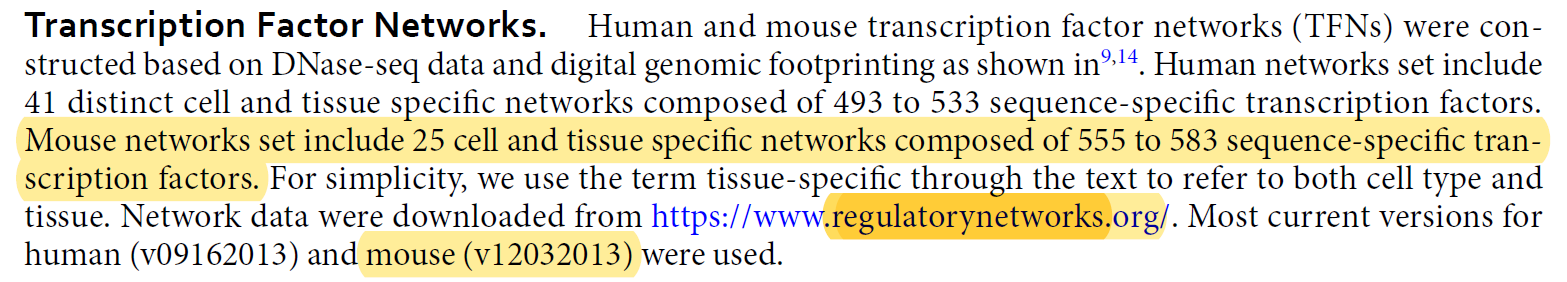

#### Auxiliar Fxns

In [5]:
def get_mouse_names(root, code_names):
    name = re.split('mouse_net', root)
    name = name[1]
    name = name.replace('/','')
    return code_names[name]

In [6]:
def extract_networks(directory_name=str, files_ignore=list, cols=tuple, feo=True, code_names=dict):
    networks = {}
    for root, dir, files in os.walk(directory_name):
        if len(files) != 0 and files[0] not in files_ignore:
          path = os.path.join(os.getcwd(), root, files[0])
          net = nx.DiGraph()
          if feo:
               f = np.genfromtxt(path, dtype= str, delimiter='\t', usecols= cols)
               net.add_edges_from(f)
          else:
               net = nx.read_edgelist(path)
          name = get_mouse_names(root, code_names)
          networks[name] = net
    return networks

#### Biological Networks

In [7]:
mm9CellTypeValues = { "m3134-DS8497" : 			  "mammary adenocarcinoma",
                        "m416B-DS14099" : 		  "CD34+ myeloid progenitor",
                        "mA20-DS16695" :            "B-lymphocyte reticulum cell sarcoma",
                        "mATn-DS17070" :            "activated T-naive cell",
                        "mATr-DS20149" :            "ATr",
                        "mB-DS16168" :              "B-cell, replicate 1",
                        "mB-DS17866" :              "B-cell, replicate 2",
                        "mBrain-DS12727" :          "normal brain",
                        "mCJ7-DS13320" :            "embryonic stem cells via 129S1/SVImJ mice",
                        "MEL-DS13036" :             "leukemia, K562 analog",
                        "mfBrain-DS14536" :         "fetal brain",
                        "mGenitalFatPad-DS18182" :  "genital adipose tissue",
                        "mHeart-DS18138" :          "normal heart",
                        "mKidney-DS13948" :         "normal kidney",
                        "mLiver-DS14605" :          "normal liver",
                        "mLung-DS14479" :           "normal lung",
                        "mNIH_3T3-DS16900" :        "fibroblast",
                        "mRetina-DS20004" :         "normal retina", 
                        "mThymus-DS18819" :         "normal thymus",
                        "mTN-DS16171" :             "TN, replicate 1",
                        "mTN-DS17080" :             "TN, replicate 2",
                        "mTR-DS17864" :             "regulatory T-cells",
                        "ZhBTc4-DS15236" :          "embryonic stem cells, +6 hrs doxycycline",
                        "ZhBTc4-DS17562" :          "embryonic stem cells, +24 hrs doxycycline",
                        "ZhBTc4-DS17616" :          "embryonic stem cells, control"
                        }

mouse_networks = extract_networks('./../../data/mouse_net/', [], (3,4), feo=True, code_names=mm9CellTypeValues)
mouse_networks

{'mammary adenocarcinoma': <networkx.classes.digraph.DiGraph at 0x2b3cd0dd790>,
 'CD34+ myeloid progenitor': <networkx.classes.digraph.DiGraph at 0x2b3d04bd490>,
 'B-lymphocyte reticulum cell sarcoma': <networkx.classes.digraph.DiGraph at 0x2b3ca0ecb50>,
 'activated T-naive cell': <networkx.classes.digraph.DiGraph at 0x2b3ca0ecaf0>,
 'ATr': <networkx.classes.digraph.DiGraph at 0x2b3ca0a2f40>,
 'B-cell, replicate 1': <networkx.classes.digraph.DiGraph at 0x2b3ca09a3d0>,
 'B-cell, replicate 2': <networkx.classes.digraph.DiGraph at 0x2b3ca07edc0>,
 'normal brain': <networkx.classes.digraph.DiGraph at 0x2b3ca09a2b0>,
 'embryonic stem cells via 129S1/SVImJ mice': <networkx.classes.digraph.DiGraph at 0x2b3cbc6ffa0>,
 'leukemia, K562 analog': <networkx.classes.digraph.DiGraph at 0x2b3ca07ecd0>,
 'fetal brain': <networkx.classes.digraph.DiGraph at 0x2b3d0402af0>,
 'genital adipose tissue': <networkx.classes.digraph.DiGraph at 0x2b3d04bd280>,
 'normal heart': <networkx.classes.digraph.DiGraph at

#### Synthetic networks

ER and BA analogous ensembles to each biological network.

from freyrelab.nets import models

seed = 42
synth_graphs = {}

for net_id, G in mouse_networks.items():
    n = G.number_of_nodes()
    m = G.number_of_edges()
    for i in range(1,101):
        synth_graphs[f'BA_{net_id}_{i}'] = nx.DiGraph(models.barabasi_albert_graph(n))
        synth_graphs[f'ER_{net_id}_{i}'] = nx.erdos_renyi_graph(n, m/(n*(n-1)), seed=seed, directed=True)

networks = {**mouse_networks, **synth_graphs}

#### Graphs overall info

In [8]:
nets_info = {'Cell Type': [],
        'Nodes': [],
        'Edges': [],
        'Density': []
        }

for name,G in mouse_networks.items():
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = n_edges / (n_nodes * (n_nodes - 1))
    nets_info['Cell Type'].append(name)
    nets_info['Nodes'].append(n_nodes)
    nets_info['Edges'].append(n_edges)
    nets_info['Density'].append(density)

info_df = pd.DataFrame.from_dict(nets_info)
info_df

,Cell Type,Nodes,Edges,Density
0,mammary adenocarcinoma,568,22301,0.069246
1,CD34+ myeloid progenitor,570,18299,0.056421
2,B-lymphocyte reticulum cell sarcoma,571,20363,0.062565
3,activated T-naive cell,579,28185,0.084219
4,ATr,575,21445,0.064975
5,"B-cell, replicate 1",574,22119,0.067251
6,"B-cell, replicate 2",555,15565,0.050623
7,normal brain,562,15652,0.049644
8,embryonic stem cells via 129S1/SVImJ mice,579,20335,0.060763
9,"leukemia, K562 analog",568,20563,0.063849


### Netective Analysis

In [2]:
from netective.structure.structure import compare_structure

`!!!!AGUAS!!!!`

Si es el bueno
100%|██████████| 25/25 [05:12<00:00, 12.52s/it]


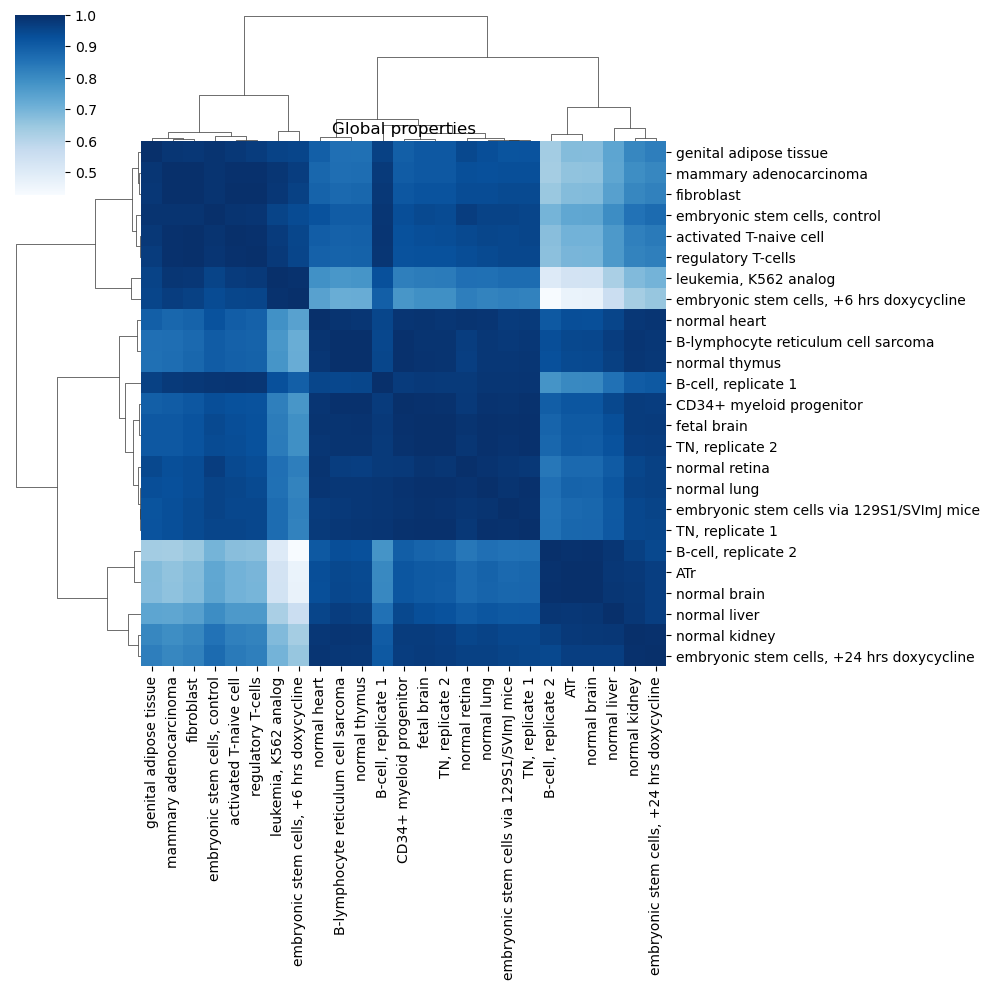

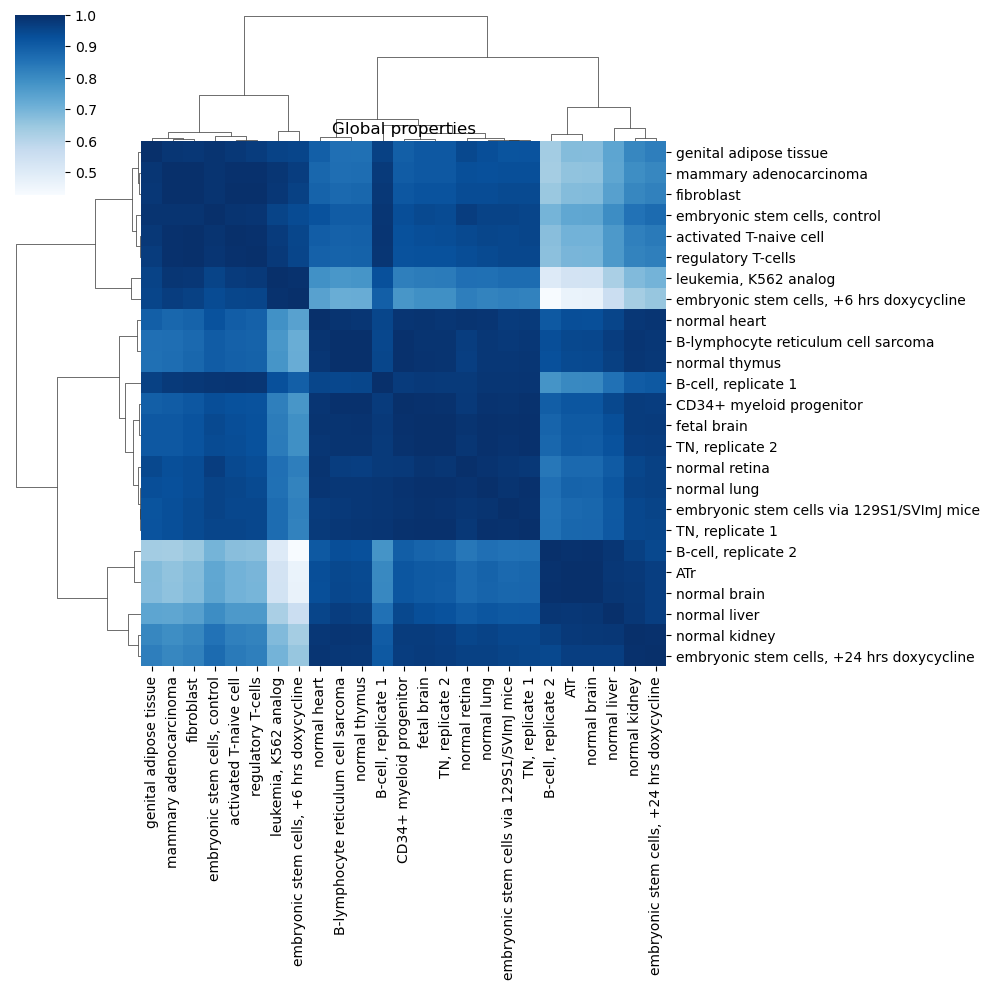

In [10]:
compare_structure(mouse_networks, norm='biological', workers='auto')